# CarDekho Kolkata Used Cars — Model Training, Tuning, Comparison & SHAP

Trains 4 models spanning different paradigms, tunes each with `RandomizedSearchCV`/`GridSearchCV`,
compares them on held-out test data, saves every trained model plus the best one, and computes
**global SHAP explainability** for each.

**Models**: Ridge (linear baseline) - Random Forest (bagging) - XGBoost (boosting) - SVR (kernel-based)

**Target transform**: `Price_INR` is right-skewed (a long tail of expensive cars) and depreciation
is multiplicative, not additive - a car loses a *percentage* of value per year, not a fixed rupee
amount. So models are trained on `log1p(Price_INR)`, and predictions are converted back to rupees
(`expm1`) before evaluation. This also means every SHAP value below is in **log-price units** -
roughly interpretable as a percentage effect on price, not a flat rupee amount. That's flagged
again at the top of the SHAP section since it changes how you'd narrate those plots.

A note on SVR: it needs feature scaling (the tree models don't), tends to underperform tree
ensembles on tabular data like this, and its SHAP support (`KernelExplainer`) is slower and only
approximate - unlike the fast, exact `TreeExplainer` used for RF/XGBoost.

Install once if needed: `pip install scikit-learn xgboost shap joblib matplotlib seaborn --break-system-packages`

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

import shap

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

C:\Users\SPANDAN CHATTERJEE\Desktop\used_car_scraper_kolkata\cars\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the ML-ready dataset

In [2]:
df = pd.read_csv("cardekho_kolkata_ml_ready.csv")

bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.shape)
df.head()

(615, 22)


,Price_INR,KM_Driven,Car_Age,Owner_Number,Latitude,Longitude,Fuel_Diesel,Fuel_Electric,Fuel_Petrol,Trans_Manual,Brand_Hyundai,Brand_Kia,Brand_MG,Brand_Mahindra,Brand_Maruti Suzuki,Brand_Mercedes-Benz,Brand_Other,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,Brand_Volkswagen
0,865000.0,65000.0,7,1.0,22.528034,88.365908,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
1,225000.0,35471.0,9,3.0,22.572600,88.363900,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0
2,591000.0,50467.0,4,1.0,22.572600,88.363900,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,277000.0,45046.0,13,1.0,22.572600,88.363900,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0
4,799000.0,22000.0,5,1.0,22.532584,88.345443,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0


## 2. Train / test split

In [3]:
X = df.drop(columns=["Price_INR"])
y = df["Price_INR"]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (492, 21)  Test: (123, 21)


## 3. Target transform: `log1p(Price)`

A quick before/after view of why this matters - the raw distribution has a long right tail;
the log version is much closer to symmetric, which is what squared-error loss (used by every
model here) implicitly assumes is well-behaved.

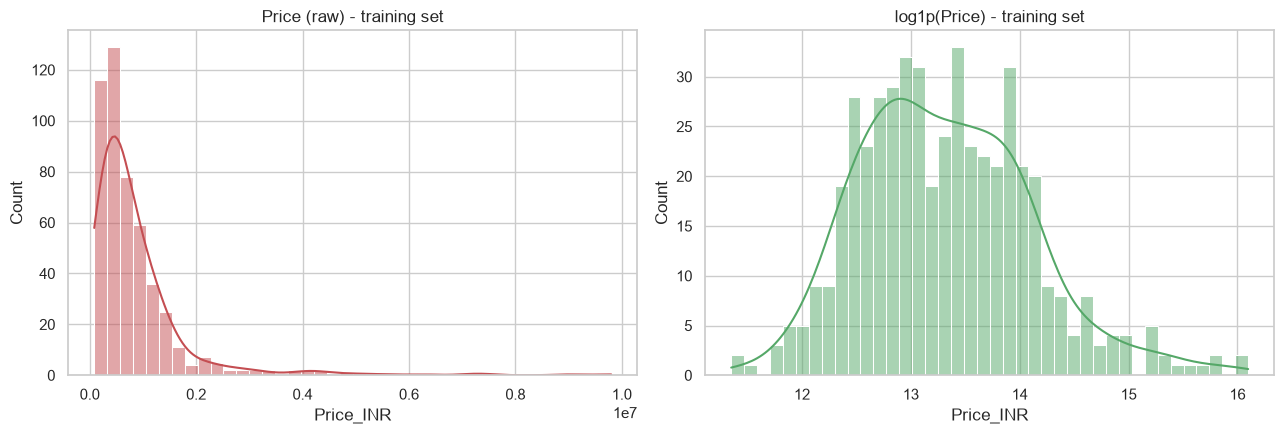

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(y_train, bins=40, kde=True, ax=axes[0], color="#C44E52")
axes[0].set_title("Price (raw) - training set")

sns.histplot(np.log1p(y_train), bins=40, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("log1p(Price) - training set")

plt.tight_layout()
plt.show()

In [5]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)  # kept only for reference/diagnostics; evaluation uses actual rupees

## 4. Scaled versions for Ridge & SVR

Tree models (RF, XGBoost) are scale-invariant - only Ridge and SVR need standardized features.
Fit the scaler on training data only, to avoid leaking test-set statistics.

In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

## 5. Hyperparameter tuning + training

Every model is tuned via cross-validated search on the **log-transformed** target, scored on R2.
After tuning, predictions are converted back to rupees (`expm1`) before computing the metrics
you'd actually report - RMSE/MAE in real rupees are far more meaningful than in log-units.

A shared `evaluate()` helper keeps metrics consistent and feeds the comparison table later.

In [7]:
results = {}
trained_models = {}
best_params = {}

def evaluate(name, y_true_actual, y_pred_log):
    y_pred_actual = np.expm1(y_pred_log)
    y_pred_actual = np.clip(y_pred_actual, a_min=0, a_max=None)  # guard against stray negative predictions

    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    r2 = r2_score(y_true_actual, y_pred_actual)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{name}: RMSE={rmse:,.0f}  MAE={mae:,.0f}  R2={r2:.4f}")

In [8]:
# --- Ridge (linear baseline) - small grid, GridSearchCV is fine ---
ridge_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid, cv=5, scoring="r2", n_jobs=-1)
ridge_search.fit(X_train_scaled, y_train_log)

ridge = ridge_search.best_estimator_
best_params["Ridge"] = ridge_search.best_params_
print("Best Ridge params:", ridge_search.best_params_)

y_pred_ridge_log = ridge.predict(X_test_scaled)
evaluate("Ridge", y_test, y_pred_ridge_log)
trained_models["Ridge"] = ridge

Best Ridge params: {'alpha': 1.0}
Ridge: RMSE=356,279  MAE=200,011  R2=0.6372


In [9]:
# --- Random Forest ---
rf_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 8, 12, 16],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.6, 1.0],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, n_iter=20, cv=5, scoring="r2", random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train, y_train_log)

rf = rf_search.best_estimator_
best_params["Random Forest"] = rf_search.best_params_
print("Best RF params:", rf_search.best_params_)

y_pred_rf_log = rf.predict(X_test)
evaluate("Random Forest", y_test, y_pred_rf_log)
trained_models["Random Forest"] = rf

Best RF params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': None}
Random Forest: RMSE=347,039  MAE=194,486  R2=0.6558


In [30]:
# --- XGBoost ---
from sklearn.metrics import mean_absolute_percentage_error

xgb_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    xgb_grid, n_iter=25, cv=5, scoring="r2", random_state=RANDOM_STATE, n_jobs=-1
)
xgb_search.fit(X_train, y_train_log)

xgb = xgb_search.best_estimator_
best_params["XGBoost"] = xgb_search.best_params_
print("Best XGBoost params:", xgb_search.best_params_)

y_pred_xgb_log = xgb.predict(X_test)
evaluate("XGBoost", y_test, y_pred_xgb_log)
y_pred_xgb = np.expm1(y_pred_xgb_log)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
print("XGBoost MAPE:", mape_xgb, "%")
trained_models["XGBoost"] = xgb

Best XGBoost params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
XGBoost: RMSE=319,337  MAE=190,256  R2=0.7086
XGBoost MAPE: 28.53559136227452 %


In [11]:
# --- SVR ---
svr_grid = {
    "C": [0.1, 1, 10, 50, 100],
    "epsilon": [0.01, 0.05, 0.1, 0.2],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf"],
}
svr_search = RandomizedSearchCV(
    SVR(), svr_grid, n_iter=25, cv=5, scoring="r2", random_state=RANDOM_STATE, n_jobs=-1
)
svr_search.fit(X_train_scaled, y_train_log)

svr = svr_search.best_estimator_
best_params["SVR"] = svr_search.best_params_
print("Best SVR params:", svr_search.best_params_)

y_pred_svr_log = svr.predict(X_test_scaled)
evaluate("SVR", y_test, y_pred_svr_log)
trained_models["SVR"] = svr

Best SVR params: {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.01, 'C': 10}
SVR: RMSE=379,471  MAE=209,887  R2=0.5885


## 6. Compare all models

In [12]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df

,RMSE,MAE,R2
XGBoost,319336.652778,190256.329522,0.708561
Random Forest,347039.109292,194485.825998,0.655803
Ridge,356279.204073,200011.281028,0.637230
SVR,379470.512111,209886.856414,0.588465


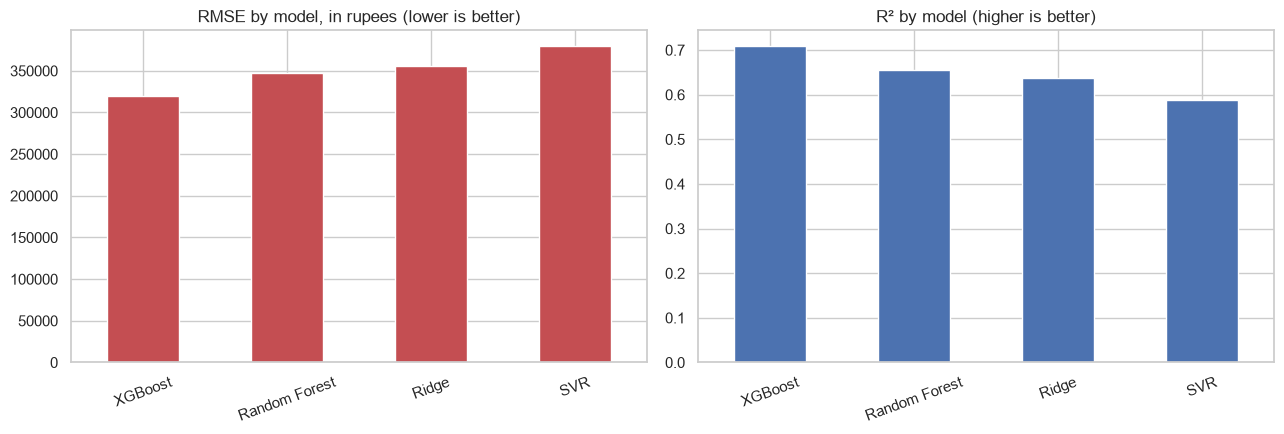

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df["RMSE"].plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("RMSE by model, in rupees (lower is better)")
axes[0].tick_params(axis="x", rotation=20)

results_df["R2"].plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].set_title("R² by model (higher is better)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 7. Save every model, and flag the best one

"Best" is chosen by test-set R2 (computed in real rupees, after inverse-transforming predictions).
All four are saved individually, plus `best_model.pkl` pointing at the winner. Note that every
saved model's raw `.predict()` output is in **log-price** - `np.expm1()` the result to get rupees.

In [14]:
import os
os.makedirs("models", exist_ok=True)

for name, model in trained_models.items():
    filename = f"models/{name.lower().replace(' ', '_')}.pkl"
    joblib.dump(model, filename)
    print(f"Saved {filename}")

joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(feature_names, "models/feature_names.pkl")
joblib.dump(best_params, "models/best_params.pkl")

best_model_name = results_df["R2"].idxmax()
best_model = trained_models[best_model_name]
joblib.dump(best_model, "models/best_model.pkl")

print(f"\nBest model: {best_model_name}  (R2 = {results_df.loc[best_model_name, 'R2']:.4f})")
print("Remember: best_model.predict(X) returns log-price - apply np.expm1() for rupees.")

Saved models/ridge.pkl
Saved models/random_forest.pkl
Saved models/xgboost.pkl
Saved models/svr.pkl

Best model: XGBoost  (R2 = 0.7086)
Remember: best_model.predict(X) returns log-price - apply np.expm1() for rupees.


## 8. Global SHAP explainability — one section per model

**Reminder**: every model here was trained on `log1p(Price)`, so every SHAP value below is in
log-price units, not rupees. A rough mental conversion: a SHAP value of `+0.10` for a feature
means that feature pushes the prediction up by roughly `exp(0.10) - 1 ≈ 10.5%`, not a fixed
rupee amount. This is arguably a *better* story for a used-car pricing project anyway - "this
feature adds about 10% to price" generalizes across the whole price range, a flat rupee number
doesn't.

Tree models get the fast, exact `TreeExplainer`. Ridge gets the exact `LinearExplainer`.
SVR gets `KernelExplainer` - explicitly noted where it differs, since it's slower and approximate.

### 8a. Ridge — `LinearExplainer`

In [15]:
explainer_ridge = shap.LinearExplainer(ridge, X_train_scaled)
shap_values_ridge = explainer_ridge(X_test_scaled)

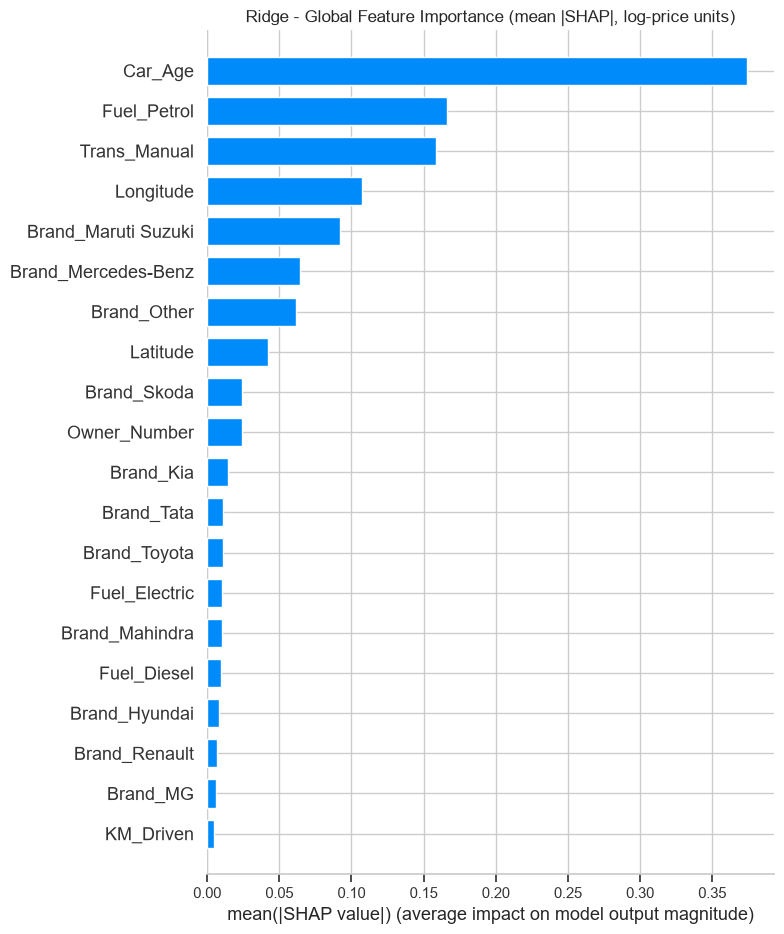

In [16]:
shap.summary_plot(shap_values_ridge, X_test_scaled, plot_type="bar", show=False)
plt.title("Ridge - Global Feature Importance (mean |SHAP|, log-price units)")
plt.tight_layout()
plt.show()

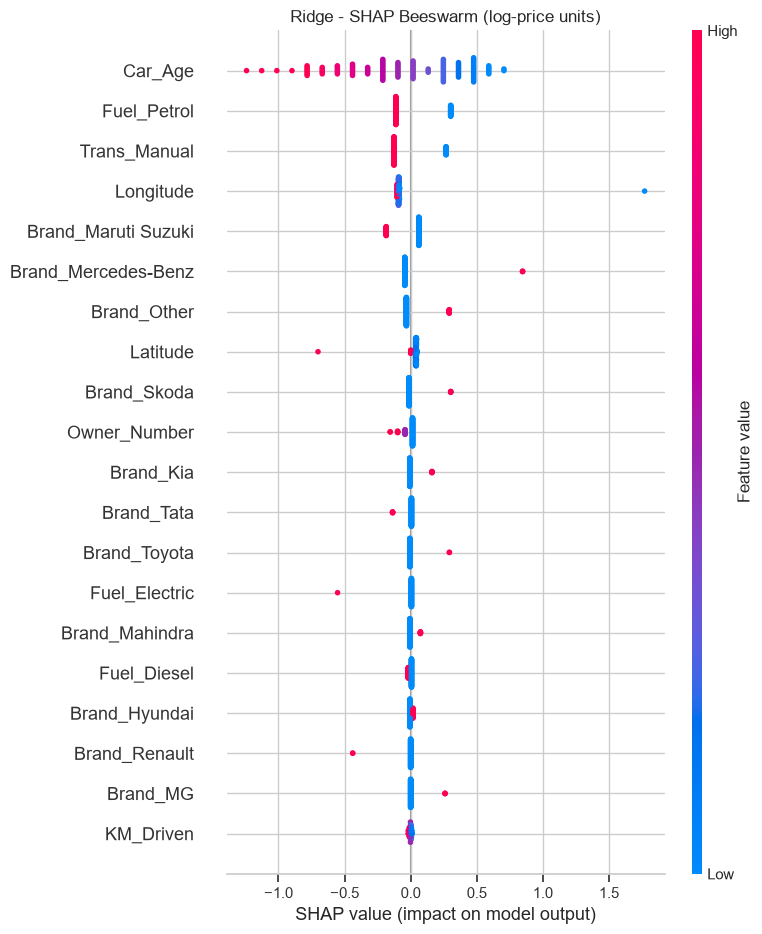

In [17]:
shap.summary_plot(shap_values_ridge, X_test_scaled, show=False)
plt.title("Ridge - SHAP Beeswarm (log-price units)")
plt.tight_layout()
plt.show()

### 8b. Random Forest — `TreeExplainer`

In [18]:
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf(X_test)

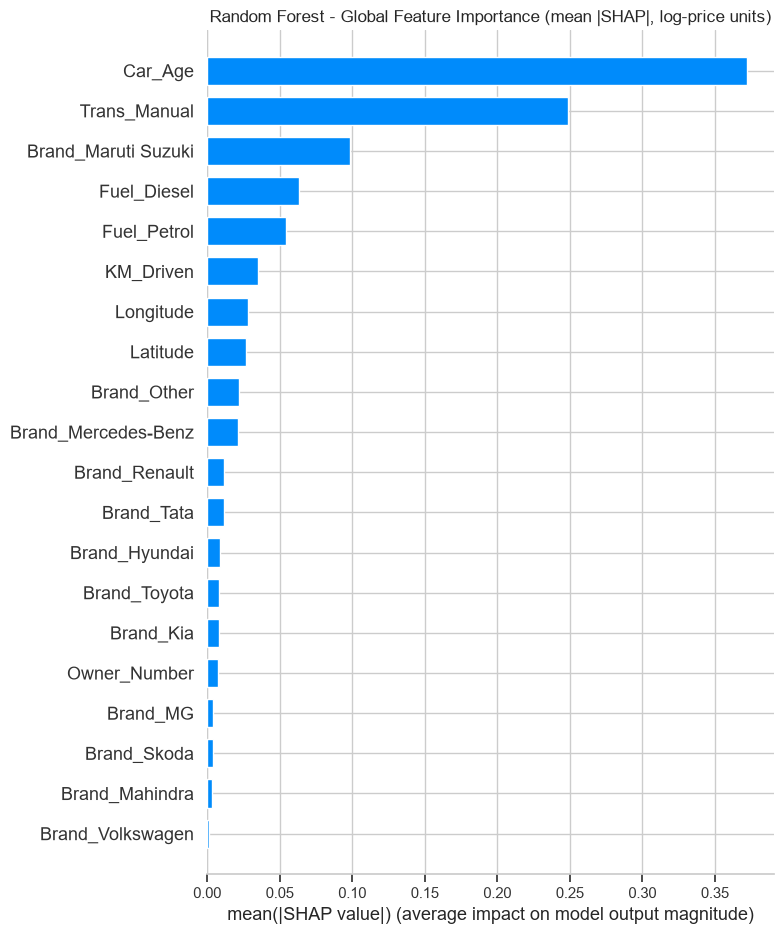

In [19]:
shap.summary_plot(shap_values_rf, X_test, plot_type="bar", show=False)
plt.title("Random Forest - Global Feature Importance (mean |SHAP|, log-price units)")
plt.tight_layout()
plt.show()

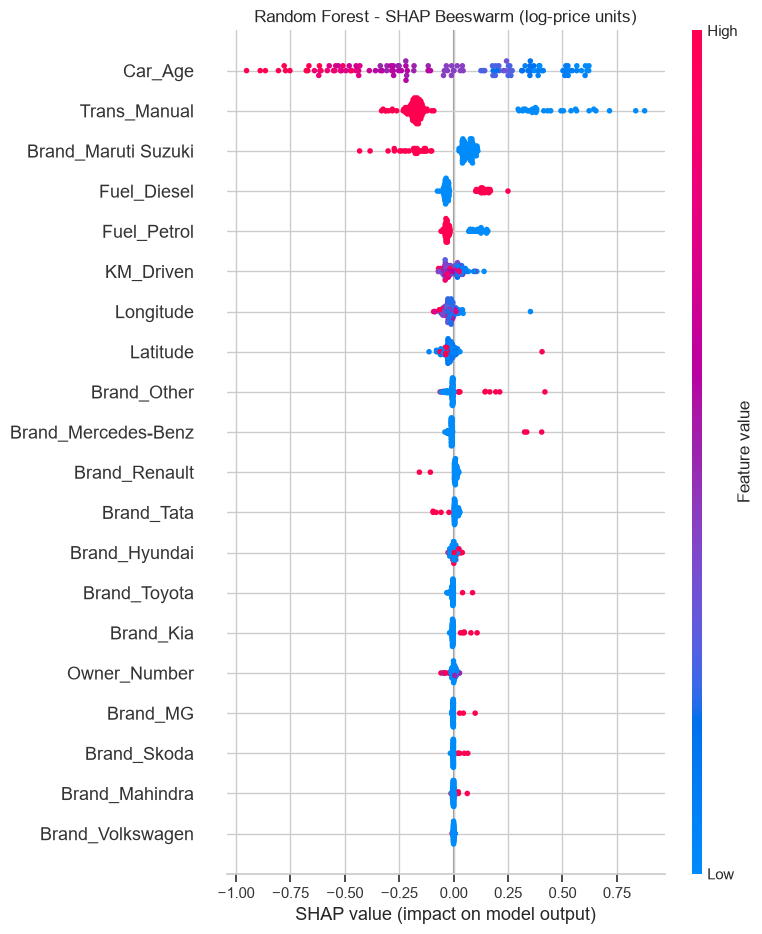

In [20]:
shap.summary_plot(shap_values_rf, X_test, show=False)
plt.title("Random Forest - SHAP Beeswarm (log-price units)")
plt.tight_layout()
plt.show()

### 8c. XGBoost — `TreeExplainer`

In [21]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb(X_test)

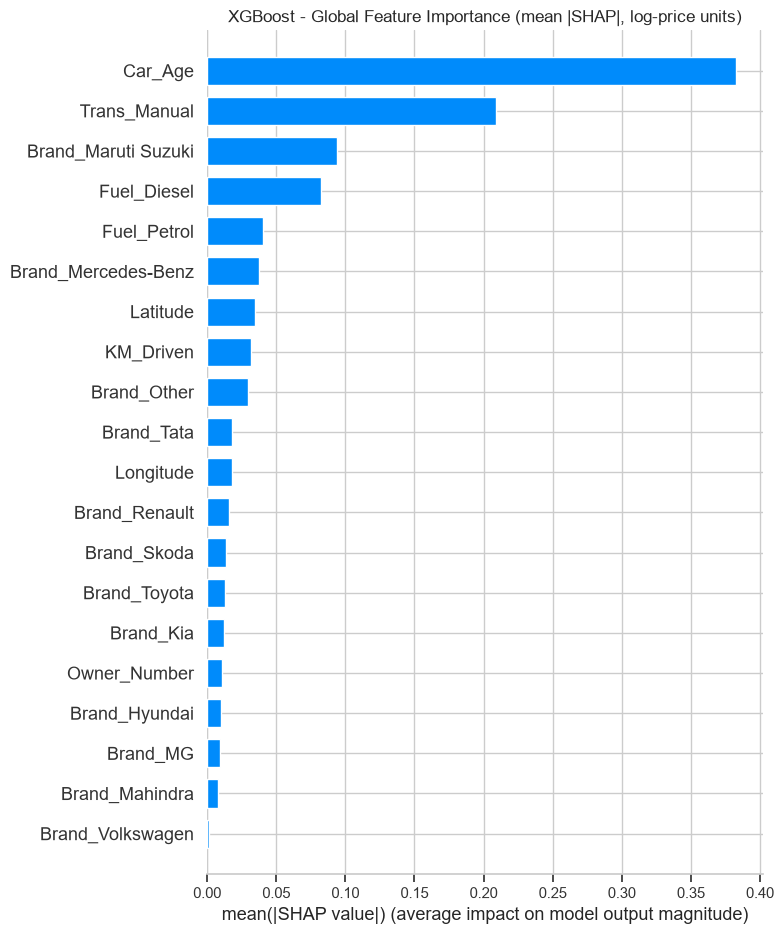

In [22]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", show=False)
plt.title("XGBoost - Global Feature Importance (mean |SHAP|, log-price units)")
plt.tight_layout()
plt.show()

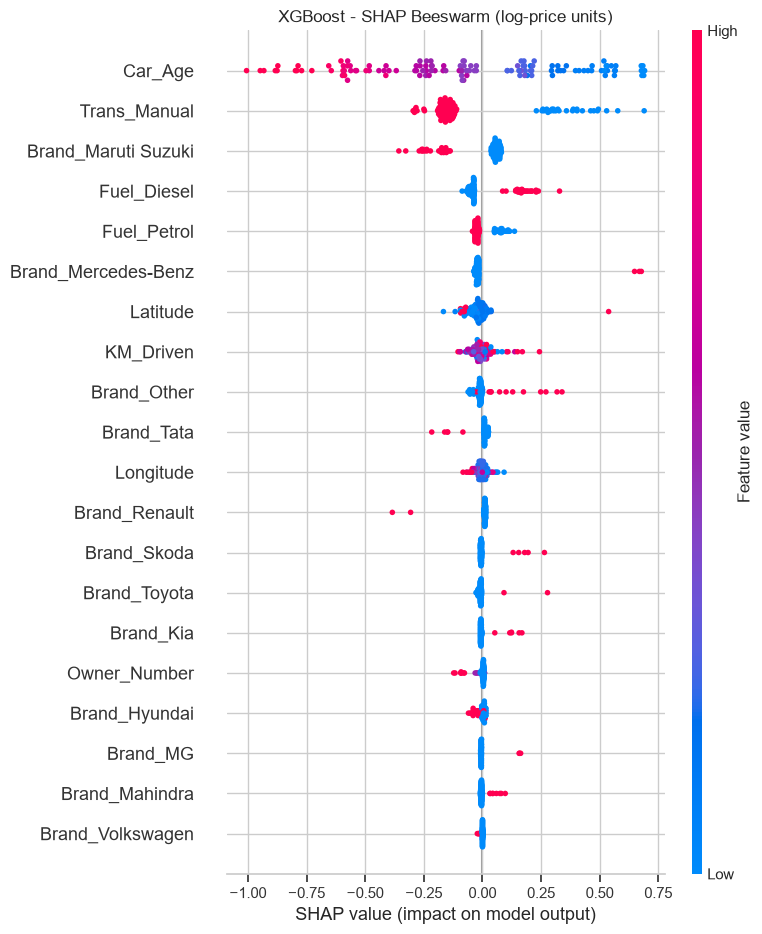

In [23]:
shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.title("XGBoost - SHAP Beeswarm (log-price units)")
plt.tight_layout()
plt.show()

### 8d. SVR — `KernelExplainer`

`KernelExplainer` is model-agnostic but computationally expensive: cost scales with
`background_size × samples_explained × features`. To keep runtime reasonable:
- **background**: a 50-row k-means summary of the training set (not the full training set)
- **explained**: only the first 100 test rows, not all of them

The global picture from 100 rows is still representative - it's just not exhaustive the way
TreeExplainer's exact computation is.

In [24]:
background = shap.kmeans(X_train_scaled, 50)
explainer_svr = shap.KernelExplainer(svr.predict, background)

X_test_svr_sample = X_test_scaled.iloc[:100]
shap_values_svr = explainer_svr.shap_values(X_test_svr_sample)

100%|██████████| 100/100 [16:06<00:00,  9.66s/it]


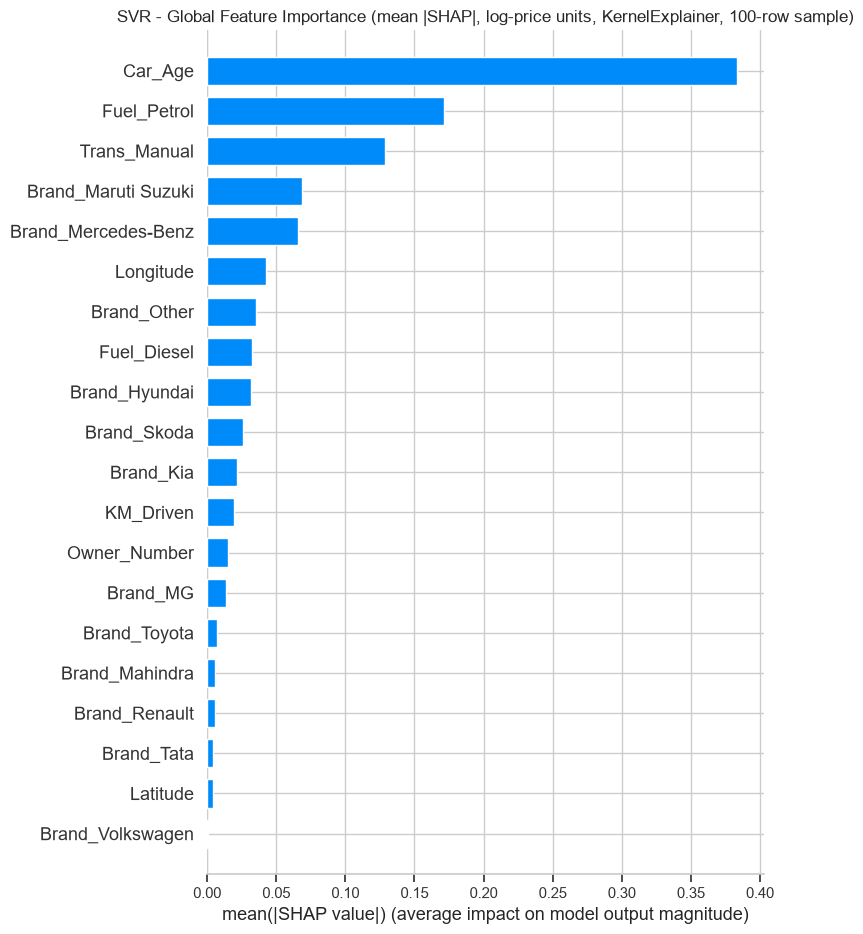

In [25]:
shap.summary_plot(shap_values_svr, X_test_svr_sample, plot_type="bar", show=False)
plt.title("SVR - Global Feature Importance (mean |SHAP|, log-price units, KernelExplainer, 100-row sample)")
plt.tight_layout()
plt.show()

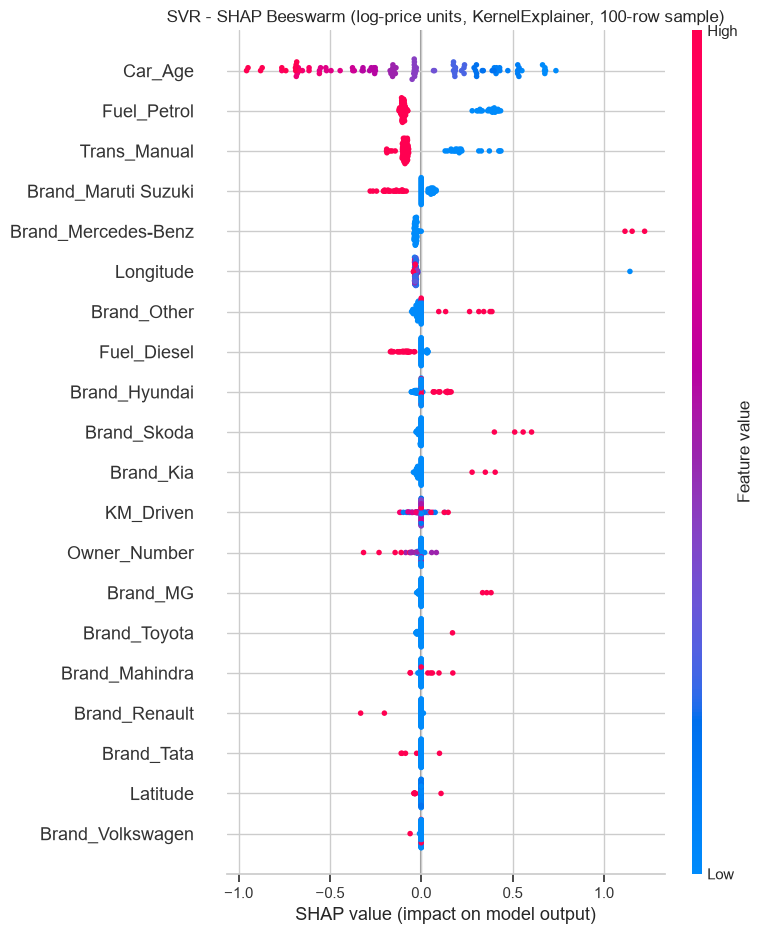

In [26]:
shap.summary_plot(shap_values_svr, X_test_svr_sample, show=False)
plt.title("SVR - SHAP Beeswarm (log-price units, KernelExplainer, 100-row sample)")
plt.tight_layout()
plt.show()

## 9. Cross-model comparison: do they agree on what matters?

If the top 2-3 features are consistent across all four models (especially the tree models vs.
Ridge), that's a strong, defensible signal for your write-up: multiple different algorithms
independently converged on the same drivers.

In [27]:
top_n = 8

top_features = {
    "Ridge": pd.Series(np.abs(shap_values_ridge.values).mean(axis=0), index=feature_names).nlargest(top_n),
    "Random Forest": pd.Series(np.abs(shap_values_rf.values).mean(axis=0), index=feature_names).nlargest(top_n),
    "XGBoost": pd.Series(np.abs(shap_values_xgb.values).mean(axis=0), index=feature_names).nlargest(top_n),
    "SVR": pd.Series(np.abs(shap_values_svr).mean(axis=0), index=feature_names).nlargest(top_n),
}

for name, feats in top_features.items():
    print(f"\n{name} - top {top_n} features:")
    print(feats.to_string())


Ridge - top 8 features:
Car_Age                0.374101
Fuel_Petrol            0.166269
Trans_Manual           0.158329
Longitude              0.106977
Brand_Maruti Suzuki    0.091798
Brand_Mercedes-Benz    0.064108
Brand_Other            0.061884
Latitude               0.042036

Random Forest - top 8 features:
Car_Age                0.372131
Trans_Manual           0.248996
Brand_Maruti Suzuki    0.098444
Fuel_Diesel            0.062945
Fuel_Petrol            0.054598
KM_Driven              0.034855
Longitude              0.027796
Latitude               0.026870

XGBoost - top 8 features:
Car_Age                0.382973
Trans_Manual           0.209009
Brand_Maruti Suzuki    0.094211
Fuel_Diesel            0.082118
Fuel_Petrol            0.040579
Brand_Mercedes-Benz    0.037357
Latitude               0.034887
KM_Driven              0.031953

SVR - top 8 features:
Car_Age                0.383500
Fuel_Petrol            0.171234
Trans_Manual           0.128390
Brand_Maruti Suzuki    0.068

In [28]:
     X_train.to_csv("models/X_train_background.csv", index=False)